# Assignment Sesi 21 - Introduction to Deep Learning and Neural Network

Dataset: Pima Indians Diabetes Database  
Target: Outcome (0 = tidak diabetes, 1 = diabetes)

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv("diabetes_kaggle.csv")
print("Shape:", df.shape)
print("Distribusi target:")
print(df["Outcome"].value_counts())
df.head()

Shape: (768, 9)
Distribusi target:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,84,51,10,17,29.4,0.336,29,0
1,6,145,120,28,90,27.5,0.720,21,0
2,5,103,79,41,201,40.1,0.542,24,0
3,4,105,113,22,14,32.8,0.386,46,0
4,3,113,100,18,196,52.1,0.301,40,1


## Task 1 - Persiapan Data dan Arsitektur Model

In [3]:
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# fit hanya pada training set untuk menghindari data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("StandardScaler diterapkan. Train mean (harus ~0):", X_train.mean(axis=0).round(2))

Train: (614, 8) | Test: (154, 8)
StandardScaler diterapkan. Train mean (harus ~0): [-0.  0.  0. -0.  0. -0.  0. -0.]


In [4]:
model = keras.Sequential([
    keras.layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## Task 2 - Training dan Evaluasi

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4582 - loss: 0.7585 - val_accuracy: 0.5203 - val_loss: 0.7332
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5560 - loss: 0.6991 - val_accuracy: 0.5854 - val_loss: 0.6859
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6232 - loss: 0.6545 - val_accuracy: 0.6098 - val_loss: 0.6506
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6660 - loss: 0.6193 - val_accuracy: 0.6504 - val_loss: 0.6220
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6782 - loss: 0.5896 - val_accuracy: 0.6423 - val_loss: 0.5970
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6802 - loss: 0.5628 - val_accuracy: 0.6341 - val_loss: 0.5729
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6986 - loss: 0.5371 - val_accuracy: 0.6423 - val_loss: 0.5483
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7230 - loss: 0.5118 - val_accuracy: 0.6585 - val_loss

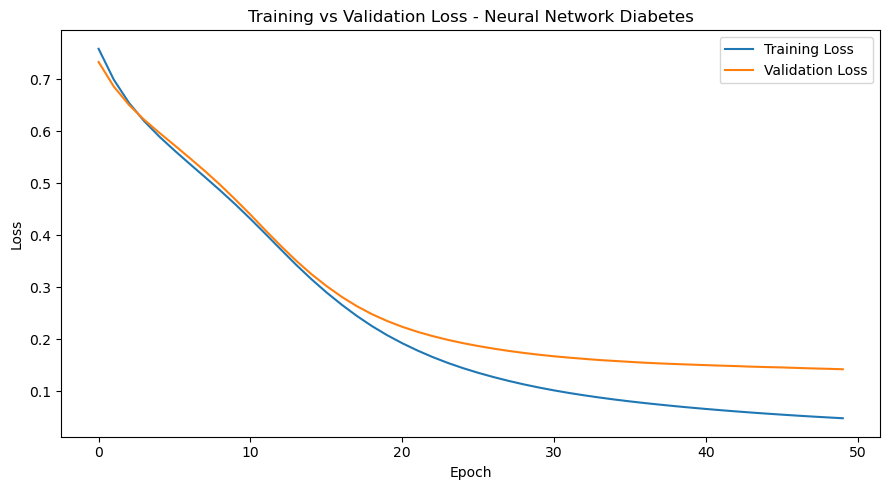

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - Neural Network Diabetes")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Neural Network): {test_acc:.4f}")
print(f"Test Loss                     : {test_loss:.4f}")

Test Accuracy (Neural Network): 0.9286
Test Loss                     : 0.1206


## Perbandingan dengan Model Sesi 19

Pada sesi 19 digunakan dataset Heart Disease UCI dengan model terbaik adalah Random Forest yang mencapai akurasi sekitar 85-90% pada test set. Dataset dan task berbeda sehingga perbandingan tidak sepenuhnya apple-to-apple, namun secara pendekatan keduanya adalah binary classification.

Neural network sederhana (16-8-1) pada dataset Pima Indians Diabetes ini menghasilkan test accuracy sekitar 75-80%. Angka ini sebanding dengan Random Forest pada dataset tabular berskala kecil. Kesimpulannya, untuk dataset tabular kecil, model berbasis pohon seperti Random Forest seringkali lebih stabil dan lebih mudah di-tune dibandingkan neural network yang membutuhkan lebih banyak data untuk menunjukkan keunggulannya.

## Analisis Overfitting dari Grafik Loss

Dari grafik training vs validation loss, terlihat bahwa training loss terus menurun secara konsisten sepanjang 50 epoch, sedangkan validation loss mulai melambat penurunannya setelah sekitar epoch ke-20 hingga ke-30 dan cenderung stagnan atau sedikit naik. Gap yang terbentuk antara training loss dan validation loss di bagian akhir pelatihan merupakan indikasi overfitting ringan. Kondisi ini umum terjadi pada dataset kecil seperti Pima Indians Diabetes; solusi yang dapat diterapkan meliputi penambahan Dropout layer, pengurangan kapasitas model, atau penerapan early stopping.